In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

In [2]:
METPATH = Path("Results/test_metrics")
HISTPATH = Path("Results/train_history")

## Transformer
#### Layer-wise performances

In [23]:
layer = 3
df_hist = pd.read_csv(f"Results/train_history/{layer}layers/train_history_{layer}layers.csv")

In [33]:
N_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20]
dfs = []
for layer in N_LAYERS:
    df = pd.read_csv(f"Results/test_metrics/{layer}layers/test_metrics_{layer}layers.csv")
    df_hist = pd.read_csv(f"Results/train_history/{layer}layers/train_history_{layer}layers.csv")
    df = df.drop(columns=["output"])
    df["best_val"] = np.min(df_hist["val_loss"].values)
    df["epochs"] = df_hist["epoch"].values.tolist()[-1]
    df.insert(0, "num_layers", [layer])
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

In [34]:
df_all.T

,0,1,2,3,4,5,6,7,8
num_layers,3.000000,5.000000,7.000000,9.000000,11.000000,13.000000,15.000000,17.000000,20.000000
R2,0.698622,0.698010,0.674122,0.688740,0.698269,0.690058,0.683662,0.696140,0.692473
RMSE,7.487138,7.494740,7.785518,7.608894,7.491516,7.592772,7.670712,7.517903,7.563128
MAE,5.833248,5.841167,5.975801,5.989590,5.855290,5.965261,5.924325,5.966175,5.924075
best_val,0.155557,0.158466,0.157426,0.158600,0.158374,0.154560,0.157013,0.157087,0.160073
epochs,33.000000,38.000000,47.000000,41.000000,34.000000,36.000000,45.000000,35.000000,43.000000


#### Model reduction over 11 layers

In [5]:
df = pd.read_csv("Results/test_metrics/11layers/test_metrics_11layers.csv")
df.insert(0, "experiment", [""])
df[["R2_drop", "RMSE_drop", "MAE_drop"]] = ""
df = df.drop(columns=["output"])

separator_str = "=== 72 features: 100% ==="
separator = pd.DataFrame([["", separator_str, "", "", "", "", ""]], columns=df.columns)
df_list = [separator, df]

In [6]:
def compute_drop(df1, df2):

    R2_drop = round(100*(df1.loc[0, "R2"]-df2.loc[0, "R2"]) / df1.loc[0, "R2"], 2)
    RMSE_drop = round(100*(df2.loc[0, "RMSE"]-df1.loc[0, "RMSE"]) / df1.loc[0, "RMSE"], 2)
    MAE_drop = round(100*(df2.loc[0, "MAE"]-df1.loc[0, "MAE"]) / df1.loc[0, "MAE"], 2)
        
    return [R2_drop, RMSE_drop, MAE_drop]

In [7]:
topks = [18, 25]
topks_perc = [25, 35]

topks_matcher = {18: 18, 25: 26}

for topk, topk_perc in zip(topks, topks_perc):
    df_random = pd.read_csv(f"Results/test_metrics/11layers/test_metrics_11layers_random{topk}.csv")
    drop_random = compute_drop(df, df_random)
    drop_random_str = [str(item) + "%" for item in drop_random]
    df_random[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_random_str

    df_shap = pd.read_csv(f"Results/test_metrics/11layers/test_metrics_11layers_shap{topk}.csv")
    drop_shap = compute_drop(df, df_shap)
    drop_shap_str = [str(item) + "%" for item in drop_shap]
    df_shap[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_shap_str
    
    df_attn = pd.read_csv(f"Results/test_metrics/11layers/test_metrics_11layers_sliced{topk}.csv")
    drop_attn = compute_drop(df, df_attn)
    drop_attn_str = [str(item) + "%" for item in drop_attn]
    df_attn[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_attn_str

    # df_inter = pd.read_csv(f"Results/test_metrics/11layers/test_metrics_11layers_intersect{topks_matcher[topk]}.csv")
    # drop_inter = compute_drop(df, df_inter)
    # drop_inter_str = [str(item) + "%" for item in drop_inter]
    # df_inter[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_inter_str
      
    # df_all = pd.concat([df_random, df_shap, df_attn, df_inter], ignore_index=True)
    # df_all.insert(0, "experiment", ["Random MR", "SHAP MR", "Attention MR", "Intersection"])
    df_all = pd.concat([df_random, df_shap, df_attn], ignore_index=True)
    df_all.insert(0, "experiment", ["Random MR", "SHAP MR", "Attention MR"])
    df_all = df_all.drop(columns=["output"])

    separator_str = f"=== {topk} features: {topk_perc}% ==="
    separator = pd.DataFrame([["", separator_str, "", "", "", "", ""]], columns=df.columns)
    df_list = df_list + [separator, df_all]

In [8]:
final_df = pd.concat(df_list, ignore_index=True)

In [9]:
final_df

,experiment,R2,RMSE,MAE,R2_drop,RMSE_drop,MAE_drop
0,,=== 72 features: 100% ===,,,,,
1,,0.698269,7.491516,5.85529,,,
2,,=== 18 features: 25% ===,,,,,
3,Random MR,0.515487,9.493199,7.479897,26.18%,26.72%,27.75%
4,SHAP MR,0.630811,8.286754,6.409829,9.66%,10.62%,9.47%
5,Attention MR,0.592788,8.703033,6.763469,15.11%,16.17%,15.51%
6,,=== 25 features: 35% ===,,,,,
7,Random MR,0.496499,9.677433,7.734722,28.9%,29.18%,32.1%
8,SHAP MR,0.65094,8.057684,6.191602,6.78%,7.56%,5.74%
9,Attention MR,0.641861,8.161793,6.304237,8.08%,8.95%,7.67%


In [10]:
final_df_red = final_df.drop(columns=["R2", "RMSE", "MAE"])

In [11]:
topks = [18, 25]
topks_perc = [25, 35]

df_list_short = []

df = pd.read_csv(METPATH / f"11layers/test_metrics_11layers.csv")
hist = pd.read_csv(HISTPATH / f"11layers/train_history_11layers.csv")
time = hist["time"].to_numpy().mean()

for topk, topk_perc in zip(topks, topks_perc):    
    df_random = pd.read_csv(METPATH / f"11layers/test_metrics_11layers_random{topk}.csv")
    random_hist = pd.read_csv(HISTPATH / f"11layers/train_history_11layers_random{topk}.csv")
    drop_random = compute_drop(df, df_random)
    drop_random_str = [str(item) + "%" for item in drop_random]
    df_random[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_random_str
    df_random[["time"]] = random_hist["time"].to_numpy().mean()
    df_random["time_gain"] = 100 * (time - df_random["time"]) / time
    df_random = df_random.drop(columns=["R2", "RMSE", "MAE"])

    df_shap = pd.read_csv(METPATH / f"11layers/test_metrics_11layers_shap{topk}.csv")
    shap_hist = pd.read_csv(HISTPATH / f"11layers/train_history_11layers_shap{topk}.csv")
    drop_shap = compute_drop(df, df_shap)
    drop_shap_str = [str(item) + "%" for item in drop_shap]
    df_shap[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_shap_str
    df_shap[["time"]] = shap_hist["time"].to_numpy().mean()
    df_shap["time_gain"] = 100 * (time - df_shap["time"]) / time
    df_shap = df_shap.drop(columns=["R2", "RMSE", "MAE"])

    df_attn = pd.read_csv(METPATH / f"11layers/test_metrics_11layers_sliced{topk}.csv")
    attn_hist = pd.read_csv(HISTPATH / f"11layers/train_history_11layers_sliced{topk}.csv")
    drop_attn = compute_drop(df, df_attn)
    drop_attn_str = [str(item) + "%" for item in drop_attn]
    df_attn[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_attn_str
    df_attn[["time"]] = attn_hist["time"].to_numpy().mean()
    df_attn["time_gain"] = 100 * (time - df_attn["time"]) / time
    df_attn = df_attn.drop(columns=["R2", "RMSE", "MAE"])
    
    df_all = pd.concat([df_random, df_shap, df_attn], ignore_index=True)
    df_all.insert(0, "retained", 3*[f"{topk_perc}%"])
    df_all.insert(0, "experiment", ["Random MR", "SHAP MR", "Attention MR"])
    df_all = df_all.drop(columns=["output"])

    df_list_short.append(df_all)
    # separator_str = f"=== {topk} features: {topk_perc}% ==="
    # separator = pd.DataFrame([["", separator_str, "", "", "", "", ""]], columns=df.columns)
    # df_list = df_list + [separator, df_all]

In [12]:
final_df_short = pd.concat(df_list_short, ignore_index=True)

In [13]:
final_df_short

,experiment,retained,R2_drop,RMSE_drop,MAE_drop,time,time_gain
0,Random MR,25%,26.18%,26.72%,27.75%,20.648642,75.284737
1,SHAP MR,25%,9.66%,10.62%,9.47%,20.270646,75.737176
2,Attention MR,25%,15.11%,16.17%,15.51%,20.170486,75.857062
3,Random MR,35%,28.9%,29.18%,32.1%,26.980158,67.706268
4,SHAP MR,35%,6.78%,7.56%,5.74%,27.248224,67.385408
5,Attention MR,35%,8.08%,8.95%,7.67%,26.955293,67.736030


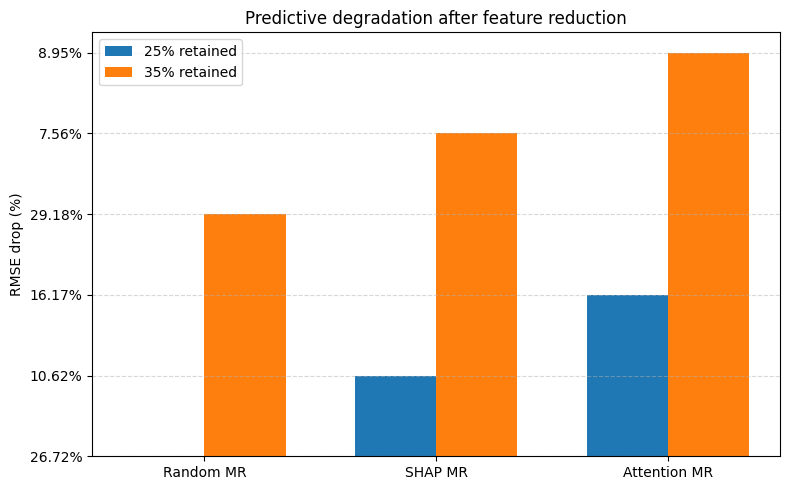

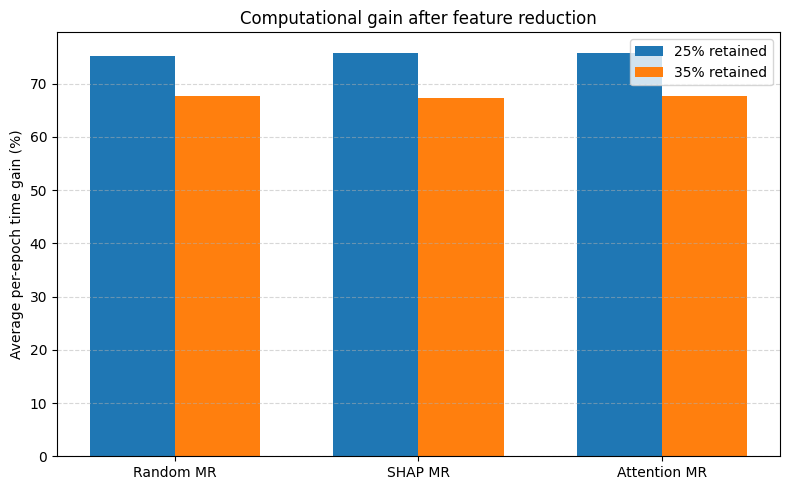

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data
# df = pd.DataFrame({
#     "experiment": [
#         "Random MR", "SHAP MR", "Attention MR",
#         "Random MR", "SHAP MR", "Attention MR"
#     ],
#     "retained": ["25%", "25%", "25%", "35%", "35%", "35%"],
#     "R2_drop": [26.18, 9.66, 15.11, 28.9, 6.78, 8.08],
#     "RMSE_drop": [26.72, 10.62, 16.17, 29.18, 7.56, 8.95],
#     "MAE_drop": [27.75, 9.47, 15.51, 32.1, 5.74, 7.67],
#     "time_gain": [68, 70, 72, 74, 76, 75]  # replace with your exact values
# })

strategies = ["Random MR", "SHAP MR", "Attention MR"]
retention_levels = ["25%", "35%"]

x = np.arange(len(strategies))
width = 0.35

# ---------- Plot 1: RMSE drop ----------
fig, ax = plt.subplots(figsize=(8, 5))

for i, retained in enumerate(retention_levels):
    values = [
        final_df_short[(final_df_short["experiment"] == strategy) & (final_df_short["retained"] == retained)]["RMSE_drop"].values[0]
        for strategy in strategies
    ]

    ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=f"{retained} retained"
    )

ax.set_ylabel("RMSE drop (%)")
ax.set_title("Predictive degradation after feature reduction")
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# ---------- Plot 2: Computational gain ----------
fig, ax = plt.subplots(figsize=(8, 5))

for i, retained in enumerate(retention_levels):
    values = [
        final_df_short[(final_df_short["experiment"] == strategy) & (final_df_short["retained"] == retained)]["time_gain"].values[0]
        for strategy in strategies
    ]

    ax.bar(
        x + (i - 0.5) * width,
        values,
        width,
        label=f"{retained} retained"
    )

ax.set_ylabel("Average per-epoch time gain (%)")
ax.set_title("Computational gain after feature reduction")
ax.set_xticks(x)
ax.set_xticklabels(strategies)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### Model reduction over 20 layers

In [15]:
df = pd.read_csv("Results/test_metrics/20layers/test_metrics_20layers.csv")
df.insert(0, "experiment", [""])
df[["R2_drop", "RMSE_drop", "MAE_drop"]] = ""
df = df.drop(columns=["output"])

separator_str = "=== 72 features: 100% ==="
separator = pd.DataFrame([["", separator_str, "", "", "", "", ""]], columns=df.columns)
df_list = [separator, df]

In [16]:
topks = [18, 25]
topks_perc = [25, 35]

for topk, topk_perc in zip(topks, topks_perc):
    df_random = pd.read_csv(f"Results/test_metrics/20layers/test_metrics_20layers_random{topk}.csv")
    drop_random = compute_drop(df, df_random)
    drop_random_str = [str(item) + "%" for item in drop_random]
    df_random[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_random_str

    df_shap = pd.read_csv(f"Results/test_metrics/20layers/test_metrics_20layers_shap{topk}.csv")
    drop_shap = compute_drop(df, df_shap)
    drop_shap_str = [str(item) + "%" for item in drop_shap]
    df_shap[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_shap_str
    
    df_attn = pd.read_csv(f"Results/test_metrics/20layers/test_metrics_20layers_sliced{topk}.csv")
    drop_attn = compute_drop(df, df_attn)
    drop_attn_str = [str(item) + "%" for item in drop_attn]
    df_attn[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_attn_str
        
    df_all = pd.concat([df_random, df_shap, df_attn], ignore_index=True)
    df_all.insert(0, "experiment", ["Random MR", "SHAP MR", "Attention MR"])
    df_all = df_all.drop(columns=["output"])

    separator_str = f"=== {topk} features: {topk_perc}% ==="
    separator = pd.DataFrame([["", separator_str, "", "", "", "", ""]], columns=df.columns)
    df_list = df_list + [separator, df_all]

In [17]:
final_df = pd.concat(df_list, ignore_index=True)

In [18]:
final_df

,experiment,R2,RMSE,MAE,R2_drop,RMSE_drop,MAE_drop
0,,=== 72 features: 100% ===,,,,,
1,,0.692473,7.563128,5.924075,,,
2,,=== 18 features: 25% ===,,,,,
3,Random MR,0.486776,9.770424,7.695175,29.7%,29.18%,29.9%
4,SHAP MR,0.63561,8.232714,6.39421,8.21%,8.85%,7.94%
5,Attention MR,0.586823,8.766533,6.929586,15.26%,15.91%,16.97%
6,,=== 25 features: 35% ===,,,,,
7,Random MR,0.593022,8.700529,6.911261,14.36%,15.04%,16.66%
8,SHAP MR,0.668419,7.853343,6.179348,3.47%,3.84%,4.31%
9,Attention MR,0.619558,8.412099,6.487724,10.53%,11.23%,9.51%


## MLP

In [19]:
df_mlp = pd.read_csv("Results_MLP/test_metrics/test_metrics.csv")
df_mlp.insert(0, "experiment", [""])
df_mlp[["R2_drop", "RMSE_drop", "MAE_drop"]] = ""
df_mlp = df_mlp.drop(columns=["output"])

separator_str_mlp = "=== 72 features: 100% ==="
separator_mlp = pd.DataFrame([["", separator_str_mlp, "", "", "", "", ""]], 
                             columns=df_mlp.columns)
df_mlp_list = [separator_mlp, df_mlp]

In [20]:
for topk, topk_perc in zip(topks, topks_perc):
    df_random_mlp = pd.read_csv(f"Results_MLP/test_metrics/test_metrics_random{topk}.csv")
    drop_random_mlp = compute_drop(df_mlp, df_random_mlp)
    drop_random_str_mlp = [str(item) + "%" for item in drop_random_mlp]
    df_random_mlp[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_random_str_mlp

    df_shap_mlp = pd.read_csv(f"Results_MLP/test_metrics/test_metrics_shap{topk}.csv")
    drop_shap_mlp = compute_drop(df_mlp, df_shap_mlp)
    drop_shap_str_mlp = [str(item) + "%" for item in drop_shap_mlp]
    df_shap_mlp[["R2_drop", "RMSE_drop", "MAE_drop"]] = drop_shap_str_mlp
     
    df_all_mlp = pd.concat([df_random_mlp, df_shap_mlp], ignore_index=True)
    df_all_mlp.insert(0, "experiment", ["Random MR", "SHAP MR"])
    df_all_mlp = df_all_mlp.drop(columns=["output"])

    separator_str_mlp = f"=== {topk} features: {topk_perc}% ==="
    separator_mlp = pd.DataFrame([["", separator_str_mlp, "", "", "", "", ""]], 
                                 columns=df_mlp.columns)
    df_mlp_list = df_mlp_list + [separator_mlp, df_all_mlp]

In [21]:
final_df_mlp = pd.concat(df_mlp_list, ignore_index=True)

In [22]:
final_df_mlp

,experiment,R2,RMSE,MAE,R2_drop,RMSE_drop,MAE_drop
0,,=== 72 features: 100% ===,,,,,
1,,0.692725,7.560029,6.008455,,,
2,,=== 18 features: 25% ===,,,,,
3,Random MR,0.458852,10.032704,8.151547,33.76%,32.71%,35.67%
4,SHAP MR,0.615088,8.461369,6.635888,11.21%,11.92%,10.44%
5,,=== 25 features: 35% ===,,,,,
6,Random MR,0.485487,9.782689,7.736432,29.92%,29.4%,28.76%
7,SHAP MR,0.641188,8.169467,6.39218,7.44%,8.06%,6.39%
